In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectFromModel, SelectPercentile, f_classif
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn import datasets, metrics, svm

In [ ]:
df = pd.read_csv('Thyroid_Diff.csv')
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

In [ ]:
df.dtypes

,0
Age,int64
Gender,object
Smoking,object
Hx Smoking,object
Hx Radiothreapy,object
Thyroid Function,object
Physical Examination,object
Adenopathy,object
Pathology,object
Focality,object


In [ ]:
df.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


In [ ]:
#to ensure there are no null values
df.isnull().sum()

,0
Age,0
Gender,0
Smoking,0
Hx Smoking,0
Hx Radiothreapy,0
Thyroid Function,0
Physical Examination,0
Adenopathy,0
Pathology,0
Focality,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = label_encoder.fit_transform(df[column])

In [ ]:
X = df.iloc[:,:-1]
X

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response
0,27,0,0,0,0,2,3,3,2,1,2,0,0,0,0,2
1,34,0,0,1,0,2,1,3,2,1,2,0,0,0,0,1
2,30,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1
3,62,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1
4,62,0,0,0,0,2,1,3,2,0,2,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,1,1,1,1,2,4,5,3,1,0,6,2,1,4,0
379,81,1,1,0,1,2,1,1,3,0,0,6,2,1,4,3
380,72,1,1,1,0,2,1,0,3,0,0,6,2,1,4,3
381,61,1,1,1,1,0,1,1,1,0,0,6,2,0,3,3


In [ ]:
y = df.iloc[:,-1:]
y

,Recurred
0,0
1,0
2,0
3,0
4,0
...,...
378,1
379,1
380,1
381,1


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
y=le.fit_transform(y)
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
print(le.classes_)

[0 1]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                test_size = 0.20,
                                                stratify = y,
                                                random_state = 42)

In [ ]:
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)

(306, 16) (77, 16) (306,) (77,)


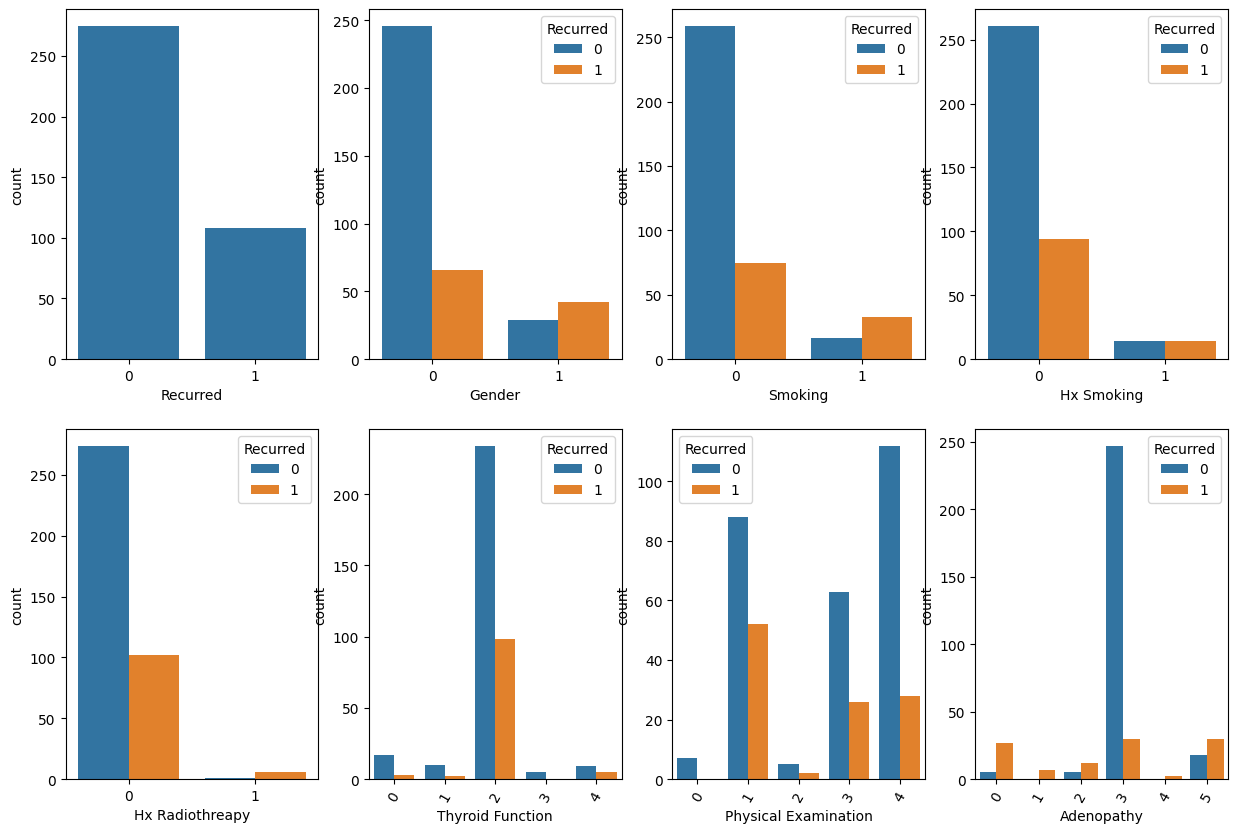

In [ ]:
plt.figure(figsize=(15,10))
plt.subplot(241)
sns.countplot(df, x='Recurred')
plt.subplot(242)
sns.countplot(df, x='Gender', hue='Recurred')
plt.subplot(243)
sns.countplot(df, x='Smoking', hue='Recurred')
plt.subplot(244)
sns.countplot(df, x='Hx Smoking', hue='Recurred')
plt.subplot(245)
sns.countplot(df, x='Hx Radiothreapy', hue ='Recurred')
plt.subplot(246)
sns.countplot(df, x='Thyroid Function', hue='Recurred')
plt.xticks(rotation=60)
plt.subplot(247)
sns.countplot(df, x='Physical Examination', hue='Recurred')
plt.xticks(rotation=60)
plt.subplot(248)
sns.countplot(df, x='Adenopathy', hue='Recurred')
plt.xticks(rotation=60)
plt.show()

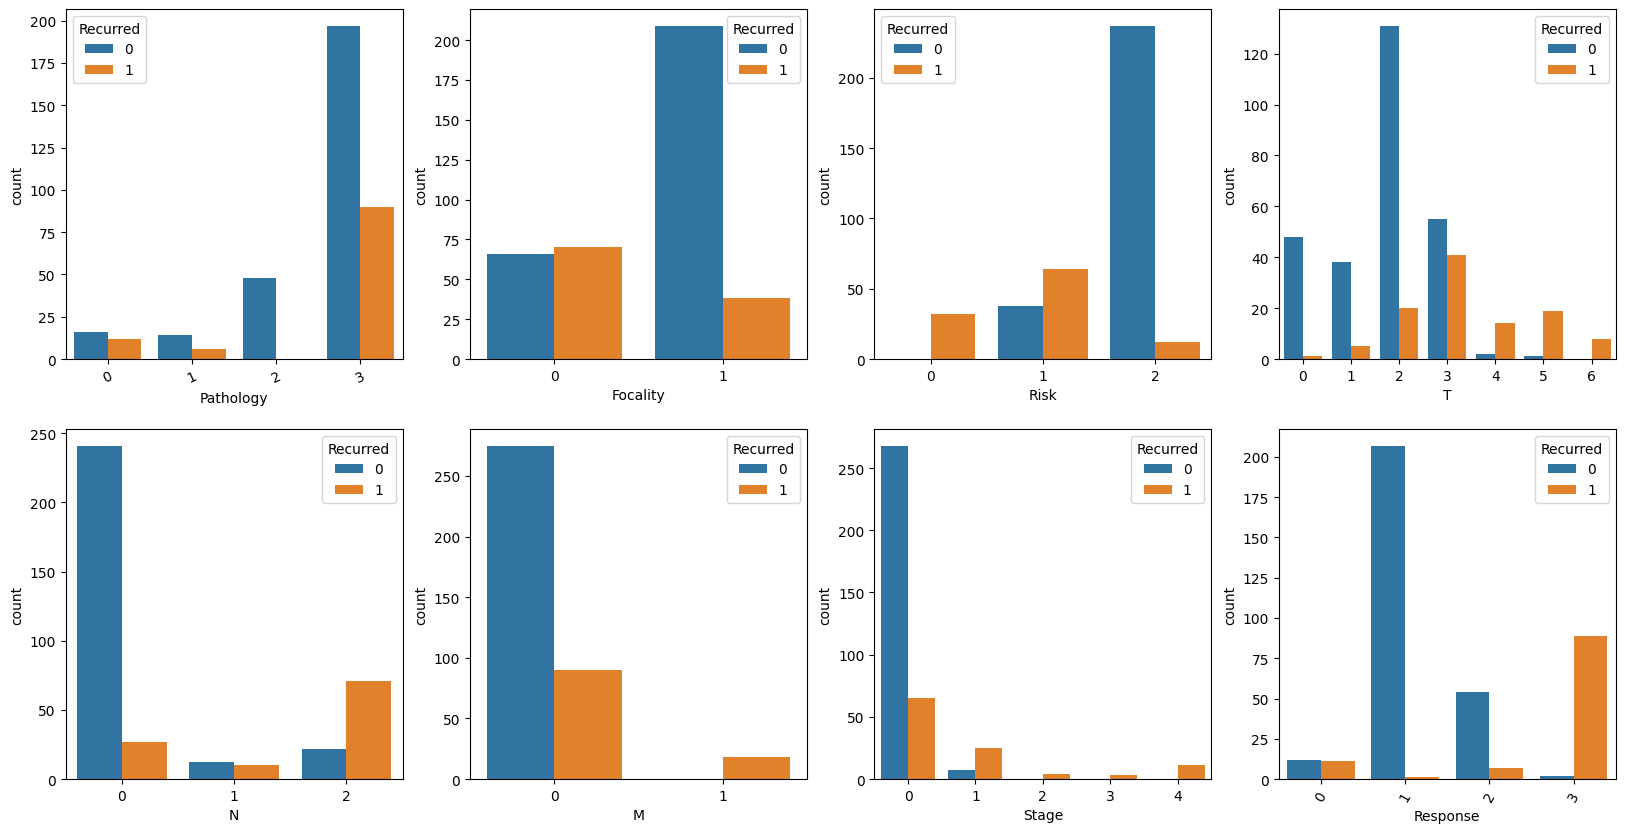

In [ ]:
plt.figure(figsize=(20,10))
plt.subplot(241)
sns.countplot(df, x='Pathology', hue='Recurred')
plt.xticks(rotation=25)
plt.subplot(242)
sns.countplot(df, x='Focality', hue='Recurred')
plt.subplot(243)
sns.countplot(df, x='Risk', hue='Recurred')
plt.subplot(244)
sns.countplot(df, x='T', hue='Recurred')
plt.subplot(245)
sns.countplot(df, x='N', hue ='Recurred')
plt.subplot(246)
sns.countplot(df, x='M', hue='Recurred')
plt.subplot(247)
sns.countplot(df, x='Stage', hue='Recurred')
plt.subplot(248)
sns.countplot(df, x='Response', hue='Recurred')
plt.xticks(rotation=60)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
pca2 = PCA(n_components=2)
pca2.fit(X_train)

X_train_2D_pca = pca2.transform(X_train)

print(f' Number of samples and attributes: {X_train_2D_pca.shape}')


 Number of samples and attributes: (306, 2)


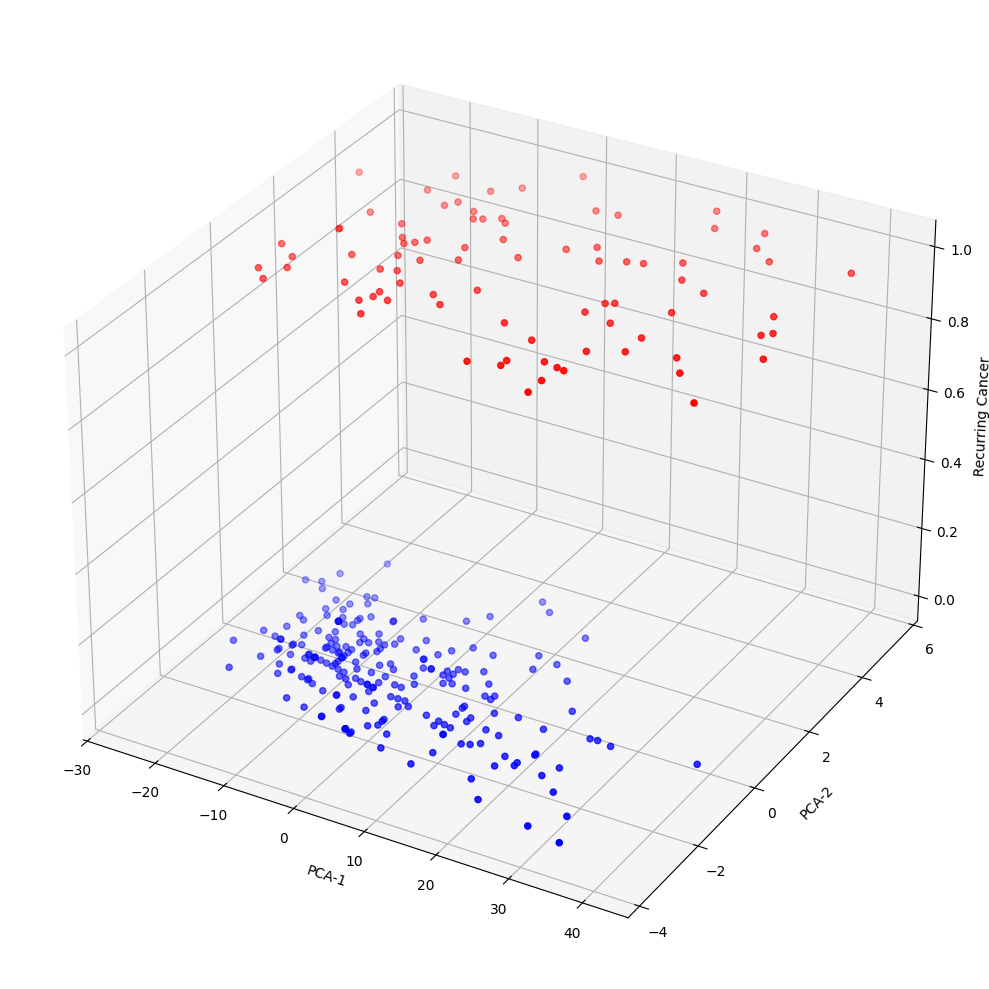

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(projection='3d')

ax.scatter(X_train_2D_pca[y_train==0, 0], X_train_2D_pca[y_train==0, 1], y_train[y_train==0], color="b");
ax.scatter(X_train_2D_pca[y_train==1, 0], X_train_2D_pca[y_train==1, 1], y_train[y_train==1], color="r");

ax.set_xlabel("PCA-1")
ax.set_ylabel("PCA-2")
ax.set_zlabel(" Recurring Cancer")

plt.tight_layout()
plt.show()

In [ ]:
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
lr_score = lr_clf.score(X_test, y_test)
print(f'Classification accuracy using raw data is {lr_score}')

Classification accuracy using raw data is 0.922077922077922


In [ ]:
lr_pred=lr_clf.predict(X_test)
print(lr_pred)
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 1
 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1
 1 0 1]
[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier LogisticRegression():
              precision    recall  f1-score   support

           0       0.96      0.93      0.94        55
           1       0.83      0.91      0.87        22

    accuracy                           0.92        77
   macro avg       0.90      0.92      0.91        77
weighted avg       0.93      0.92      0.92        77




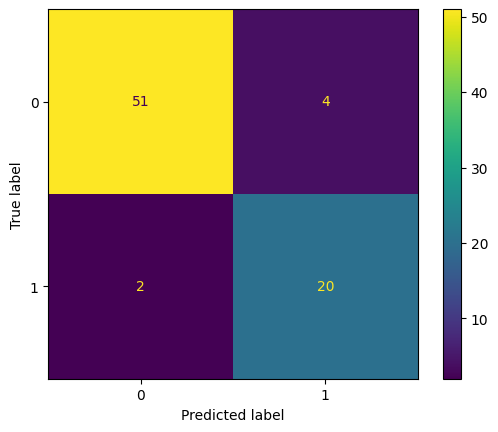

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (lr_clf, metrics.classification_report(y_test, lr_pred)))

confMatrix = confusion_matrix(y_true = y_test, y_pred = lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = lr_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = lr_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = lr_pred))

Precision: 0.833
Recall: 0.909
F1: 0.870


In [ ]:
lr_cv = cross_val_score(lr_clf, X, y, cv=10, scoring='f1_weighted')

print(lr_cv)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[0.70532544 0.94703802 0.72820513 0.97322253 1.         0.82039474
 0.97329688 0.6159912  0.94854926 0.51447368]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
print("%0.3f +/- %.3f" % (lr_cv.mean(), lr_cv.std()))

0.823 +/- 0.164


# **Standard Scaling**

In [ ]:
sc = StandardScaler()
sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)


# **SVM(Linear)**

In [ ]:
linearSVM = svm.SVC(kernel='linear')
linearSVM.fit(X_train, y_train)
predicted = linearSVM.predict(X_test)
lin_score=linearSVM.score(X_test,y_test)
print(f'the classification accuracy of the raw data is: {lin_score}')


the classification accuracy of the raw data is: 0.8961038961038961


In [ ]:
svm_pred = linearSVM.predict(X_test)
print(svm_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 1
 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1
 1 0 1]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier SVC(kernel='linear'):
              precision    recall  f1-score   support

           0       0.94      0.91      0.93        55
           1       0.79      0.86      0.83        22

    accuracy                           0.90        77
   macro avg       0.87      0.89      0.88        77
weighted avg       0.90      0.90      0.90        77




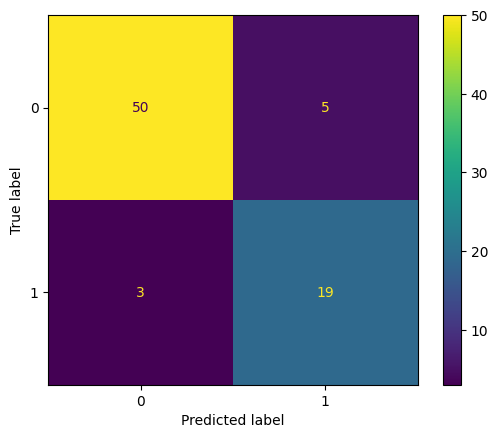

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (linearSVM, metrics.classification_report(y_test, svm_pred)))

confMatrix = confusion_matrix(y_true = y_test, y_pred = svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = svm_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = svm_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = svm_pred))

Precision: 0.792
Recall: 0.864
F1: 0.826


In [ ]:
lin_cv = cross_val_score(linearSVM, X, y, cv=10, scoring='f1_weighted')

print(lin_cv)

[0.85819549 0.9739734  0.78860399 0.94535189 1.         0.85464659
 0.97329688 0.69766746 0.94854926 0.60936645]


In [ ]:
print("%0.2f +/- %.2f" % (lin_cv.mean(), lin_cv.std()))

0.86 +/- 0.12


In [ ]:
linearSVM_std = svm.SVC(kernel='linear')
linearSVM_std.fit(X_train_std, y_train)

lin_predicted = linearSVM_std.predict(X_test_std)

lin_score_std=linearSVM_std.score(X_test_std,y_test)
print(f'The classification score after scaling is:{lin_score_std}')


The classification score after scaling is:0.9090909090909091


In [ ]:
svmstd_pred = linearSVM_std.predict(X_test_std)
print(svmstd_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 1
 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier SVC(kernel='linear'):
              precision    recall  f1-score   support

           0       0.94      0.93      0.94        55
           1       0.83      0.86      0.84        22

    accuracy                           0.91        77
   macro avg       0.89      0.90      0.89        77
weighted avg       0.91      0.91      0.91        77




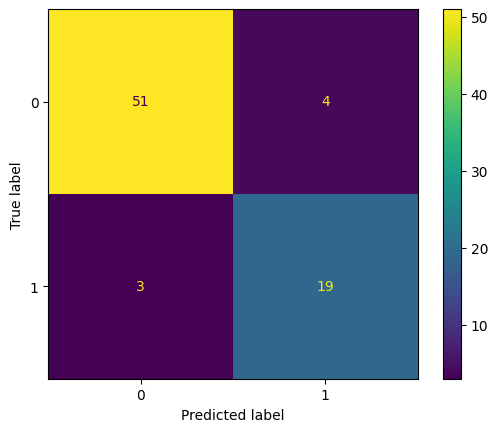

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (linearSVM_std, metrics.classification_report(y_test, svmstd_pred)))


from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

confMatrix = confusion_matrix(y_true = y_test, y_pred = svmstd_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = svmstd_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = svmstd_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = svmstd_pred))

Precision: 0.826
Recall: 0.864
F1: 0.844


In [ ]:
from sklearn.model_selection import cross_val_score
linstd_cv = cross_val_score(linearSVM_std, X, y, cv=10, scoring='f1_weighted')

print(linstd_cv)

[0.85819549 0.9739734  0.78860399 0.94535189 1.         0.85464659
 0.97329688 0.69766746 0.94854926 0.60936645]


In [ ]:
print("%0.2f +/- %.2f" % (linstd_cv.mean(), linstd_cv.std()))

0.86 +/- 0.12


# **SVM(Polynomial)**

In [ ]:
Polynomial_SVM=svm.SVC(kernel="poly")
Polynomial_SVM.fit(X_train, y_train)
pred = Polynomial_SVM.predict(X_test)
poly_score=Polynomial_SVM.score(X_test,y_test)
print(f'the classification accuracy sof the raw data before scaling is: {poly_score}')

the classification accuracy sof the raw data before scaling is: 0.8441558441558441


In [ ]:
poly_pred = Polynomial_SVM.predict(X_test)
print(poly_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0
 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier SVC(kernel='poly'):
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        55
           1       1.00      0.45      0.62        22

    accuracy                           0.84        77
   macro avg       0.91      0.73      0.76        77
weighted avg       0.87      0.84      0.82        77




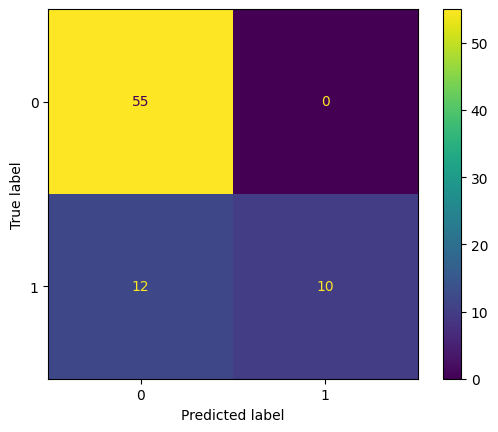

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (Polynomial_SVM, metrics.classification_report(y_test, poly_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = poly_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = poly_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = poly_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = poly_pred))

Precision: 1.000
Recall: 0.455
F1: 0.625


In [ ]:
from sklearn.model_selection import cross_val_score
poly_cv = cross_val_score(Polynomial_SVM, X, y, cv=10, scoring='f1_weighted')

print(poly_cv)

[0.60007654 0.65617716 0.70532544 0.62519936 0.85188381 0.64775219
 0.74290565 0.79650522 0.97329688 0.87244582]


In [ ]:
print("%0.2f +/- %.2f" % (poly_cv.mean(), poly_cv.std()))

0.75 +/- 0.12


In [ ]:
Polynomial_SVM_std = svm.SVC(kernel='poly')
Polynomial_SVM_std.fit(X_train_std, y_train)

std_pred = Polynomial_SVM_std.predict(X_test_std)

polystd_score_std=Polynomial_SVM_std.score(X_test_std,y_test)
print(f'The classification score after scaling is:{polystd_score_std}')


The classification score after scaling is:0.9090909090909091


In [ ]:
polystd_pred = Polynomial_SVM_std.predict(X_test_std)
print(polystd_pred)

print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 1 0 0]
[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier SVC(kernel='poly'):
              precision    recall  f1-score   support

           0       0.90      0.98      0.94        55
           1       0.94      0.73      0.82        22

    accuracy                           0.91        77
   macro avg       0.92      0.85      0.88        77
weighted avg       0.91      0.91      0.91        77




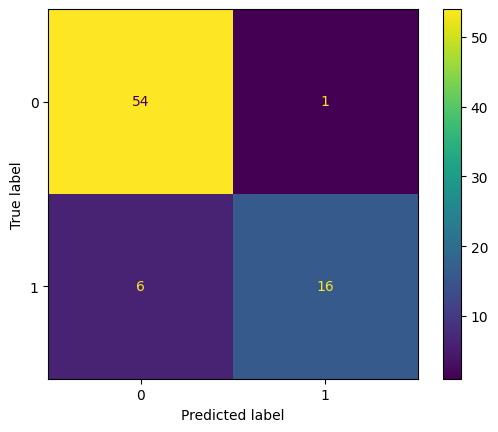

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (Polynomial_SVM_std, metrics.classification_report(y_test, polystd_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = polystd_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = polystd_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = polystd_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = polystd_pred))

Precision: 0.941
Recall: 0.727
F1: 0.821


In [ ]:
from sklearn.model_selection import cross_val_score
polystd_cv = cross_val_score(Polynomial_SVM_std, X, y, cv=10, scoring='f1_weighted')

print(polystd_cv)

[0.60007654 0.65617716 0.70532544 0.62519936 0.85188381 0.64775219
 0.74290565 0.79650522 0.97329688 0.87244582]


In [ ]:
print("%0.2f +/- %.2f" % (polystd_cv.mean(), polystd_cv.std()))

0.75 +/- 0.12


# **SVM(RBF)**

In [ ]:
kernelSVM = svm.SVC(kernel='rbf')
kernelSVM.fit(X_train, y_train)

SVC()

In [ ]:
kernelSVM = svm.SVC(kernel='rbf')
kernelSVM.fit(X_train, y_train)

predicted = kernelSVM.predict(X_test)
score=kernelSVM.score(X_test,y_test)

print(f"The classifcation accuracy before scaling is:{score}")

The classifcation accuracy before scaling is:0.7662337662337663


In [ ]:
ker_pred = kernelSVM.predict(X_test)
print(ker_pred)

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier SVC():
              precision    recall  f1-score   support

           0       0.77      0.96      0.85        55
           1       0.75      0.27      0.40        22

    accuracy                           0.77        77
   macro avg       0.76      0.62      0.63        77
weighted avg       0.76      0.77      0.72        77




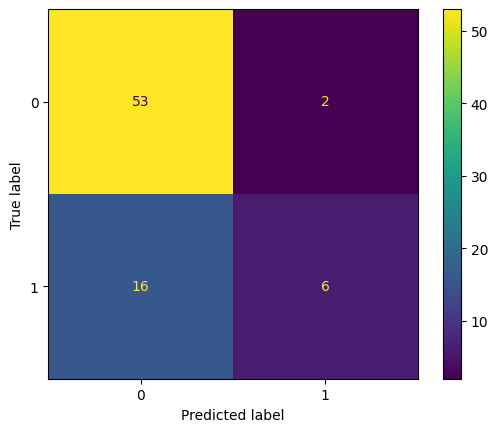

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (kernelSVM, metrics.classification_report(y_test, ker_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = ker_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
ker_cv = cross_val_score(kernelSVM, X, y, cv=10, scoring='f1_weighted')

print(ker_cv)

[0.57435897 0.60007654 0.70532544 0.61214575 0.73245614 0.64775219
 0.67863206 0.69809138 0.91689751 0.94736842]


In [ ]:
print("%0.2f +/- %.2f" % (ker_cv.mean(), ker_cv.std()))

0.71 +/- 0.12


# **Kernel SVM after scaling**

In [ ]:
kernelSVM_std = svm.SVC(kernel='rbf')
kernelSVM_std.fit(X_train_std, y_train)

predicted = kernelSVM_std.predict(X_test_std)

kernel_score=kernelSVM_std.score(X_test_std,y_test)
print(f"the classification score after standard scaling is: {kernel_score}")

the classification score after standard scaling is: 0.948051948051948


In [ ]:
kerstd_pred = kernelSVM_std.predict(X_test_std)
print(kerstd_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier SVC():
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        55
           1       0.95      0.86      0.90        22

    accuracy                           0.95        77
   macro avg       0.95      0.92      0.93        77
weighted avg       0.95      0.95      0.95        77




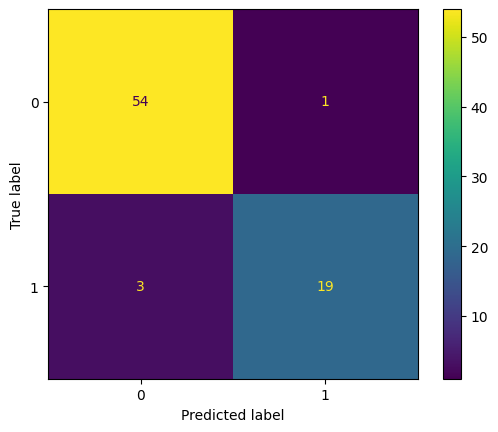

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (kernelSVM_std, metrics.classification_report(y_test, kerstd_pred)))



confMatrix = confusion_matrix(y_true = y_test, y_pred = kerstd_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = kerstd_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = kerstd_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = kerstd_pred))

Precision: 0.950
Recall: 0.864
F1: 0.905


In [ ]:
kerstd_cv = cross_val_score(kernelSVM_std, X, y, cv=10, scoring='f1_weighted')

print(kerstd_cv)

[0.57435897 0.60007654 0.70532544 0.61214575 0.73245614 0.64775219
 0.67863206 0.69809138 0.91689751 0.94736842]


In [ ]:
print("%0.2f +/- %.2f" % (kerstd_cv.mean(), kerstd_cv.std()))

0.71 +/- 0.12


In [ ]:
kernelSVM_hpt = SVC(kernel='rbf')

In [ ]:
kernelSVM_hpt.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [ ]:
hpt_param_grid = [
    {
     'C':[i for i in range(1,10)],
     'gamma': np.linspace(0.1, 1, 10)
     }
     ]

In [ ]:
hpt_param_grid

[{'C': [1, 2, 3, 4, 5, 6, 7, 8, 9],
  'gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])}]

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
grid_search = GridSearchCV(estimator = kernelSVM_hpt,
                           param_grid = hpt_param_grid,
                           cv = 5)

In [ ]:
grid_search.fit(X_train_std, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [1, 2, 3, 4, 5, 6, 7, 8, 9],
                          'gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])}])

In [ ]:
print(grid_search.best_params_)

{'C': 6, 'gamma': np.float64(0.1)}


In [ ]:
print(grid_search.best_score_)

0.9248016922263351


In [ ]:
kernelSVM_hpt = SVC(kernel='rbf',C=6, gamma=0.1, random_state=42)

kernelSVM_hpt.fit(X_train_std, y_train)
score_svc_rbf = kernelSVM_hpt.score(X_test_std, y_test)

print(score_svc_rbf)

0.961038961038961


In [ ]:
kerstd_hpt = kernelSVM_hpt.predict(X_test_std)
print(kerstd_hpt)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 1 0 1]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier SVC(C=6, gamma=0.1, random_state=42):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        55
           1       0.95      0.91      0.93        22

    accuracy                           0.96        77
   macro avg       0.96      0.95      0.95        77
weighted avg       0.96      0.96      0.96        77




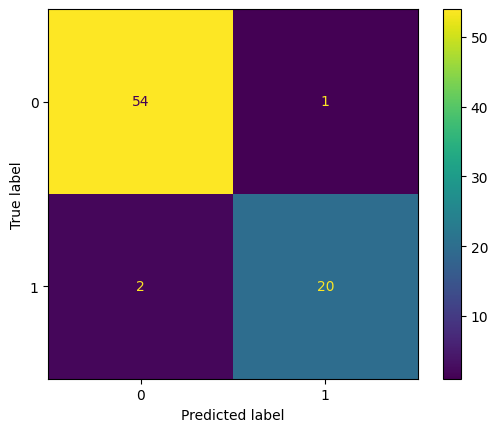

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (kernelSVM_hpt, metrics.classification_report(y_test, kerstd_hpt)))

confMatrix = confusion_matrix(y_true = y_test, y_pred = kerstd_hpt)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
rbfhpt_cv = cross_val_score(kernelSVM_hpt, X, y, cv=5, scoring='f1_weighted')

print(rbfhpt_cv)

print("%0.2f +/- %.2f" % (rbfhpt_cv.mean(), rbfhpt_cv.std()))

[0.78602151 0.82773109 0.86010223 0.78776205 0.77551487]
0.81 +/- 0.03


In [ ]:
hpt_param_dict = {
    'C':[i for i in range(1,10)],
    'gamma': np.linspace(0.1, 1, 10)
    }

In [ ]:
hpt_param_dict

{'C': [1, 2, 3, 4, 5, 6, 7, 8, 9],
 'gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
kernelrandom_hpt=SVC(kernel='rbf')

In [ ]:
random_search = RandomizedSearchCV(estimator = kernelSVM_hpt,
                                   param_distributions=hpt_param_dict,
                                   cv=5)


In [ ]:
random_search.fit(X_train_std, y_train)

RandomizedSearchCV(cv=5, estimator=SVC(C=6, gamma=0.1, random_state=42),
                   param_distributions={'C': [1, 2, 3, 4, 5, 6, 7, 8, 9],
                                        'gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])})

In [ ]:
random_search.best_params_

{'gamma': np.float64(0.1), 'C': 7}

In [ ]:
random_search.best_score_

np.float64(0.921523003701745)

In [ ]:
random_search.best_estimator_

SVC(C=5, gamma=np.float64(0.1), random_state=42)

In [ ]:
kernelrandom_hpt = SVC(kernel='rbf',C=7, gamma=0.1, random_state=42)

kernelrandom_hpt.fit(X_train_std, y_train)
score_svc_hpt = kernelrandom_hpt.score(X_test_std, y_test)

print(score_svc_hpt)

0.961038961038961


In [ ]:
kerran_hpt = kernelrandom_hpt.predict(X_test_std)
print(kerran_hpt)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 1 0 1]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier SVC(C=7, gamma=0.1, random_state=42):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        55
           1       0.95      0.91      0.93        22

    accuracy                           0.96        77
   macro avg       0.96      0.95      0.95        77
weighted avg       0.96      0.96      0.96        77




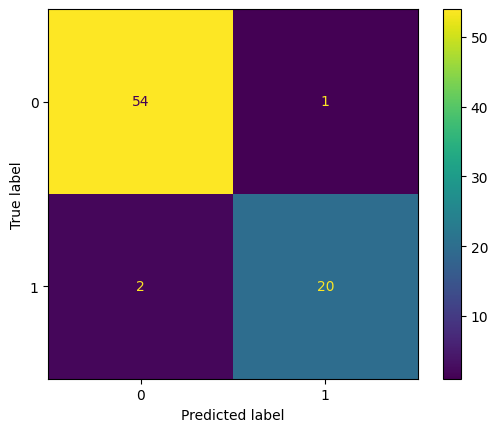

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (kernelrandom_hpt, metrics.classification_report(y_test, kerran_hpt)))

confMatrix = confusion_matrix(y_true = y_test, y_pred = kerran_hpt)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
rbfran_cv = cross_val_score(kernelrandom_hpt, X, y, cv=5, scoring='f1_weighted')

print(rbfran_cv)

print("%0.2f +/- %.2f" % (rbfran_cv.mean(), rbfran_cv.std()))

[0.78602151 0.82773109 0.86010223 0.78776205 0.77551487]
0.81 +/- 0.03


# **Decision Trees**

In [ ]:
tree_clf = DecisionTreeClassifier(max_depth=4)
tree_clf.fit(X_train, y_train)
dt_predicted =tree_clf.predict(X_test)
score = tree_clf.score(X_test, y_test)
print(f'Classification accuracy using raw data is {score}')

Classification accuracy using raw data is 0.961038961038961


In [ ]:
tree_pred = tree_clf.predict(X_test)
print(tree_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier DecisionTreeClassifier(max_depth=4):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        55
           1       1.00      0.86      0.93        22

    accuracy                           0.96        77
   macro avg       0.97      0.93      0.95        77
weighted avg       0.96      0.96      0.96        77




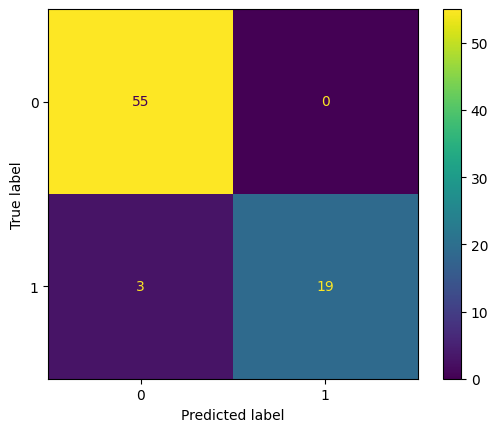

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (tree_clf, metrics.classification_report(y_test, tree_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = tree_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()


In [ ]:
dt_cv = cross_val_score(tree_clf, X, y, cv=5, scoring='f1_weighted')

print(dt_cv)

[0.94636591 0.93231406 0.94727891 0.98674091 0.72409539]


In [ ]:
print("%0.2f +/- %.2f" % (dt_cv.mean(), dt_cv.std()))

0.91 +/- 0.09


In [ ]:
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)
tree_clf_std=DecisionTreeClassifier()
tree_clf_std.fit(X_train_std, y_train)
dt_score_std = tree_clf_std.score(X_test_std, y_test)
print(f'Classification accuracy after feature standard scaling is {dt_score_std}')

Classification accuracy after feature standard scaling is 0.935064935064935


In [ ]:
y_pred = tree_clf_std.predict(X_test_std)
print(y_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier DecisionTreeClassifier():
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        55
           1       0.90      0.86      0.88        22

    accuracy                           0.94        77
   macro avg       0.93      0.91      0.92        77
weighted avg       0.93      0.94      0.93        77




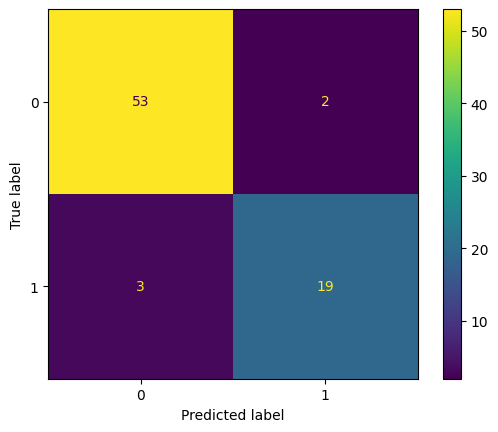

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (tree_clf_std, metrics.classification_report(y_test, y_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
dtstd_cv = cross_val_score(tree_clf_std, X, y, cv=5, scoring='f1_weighted')

print(dtstd_cv)

[0.94636591 0.94727891 0.91954887 0.88386621 0.73713779]


In [ ]:
print("%0.2f +/- %.2f" % (dtstd_cv.mean(), dtstd_cv.std()))

0.89 +/- 0.08


In [ ]:
dt_hpt=DecisionTreeClassifier(max_depth=3)

In [ ]:
dt_hpt.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [ ]:
dt_hpt_param_grid = [
    {
     'max_depth':[1,2,3],
     'min_samples_leaf':[int(i) for i in np.linspace(1, 10, 10)],
     }
     ]

In [ ]:
dt_hpt_param_grid

[{'max_depth': [1, 2, 3], 'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}]

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
dt_grid_search = GridSearchCV(estimator = dt_hpt,
                           param_grid = dt_hpt_param_grid,
                           cv = 5)

In [ ]:
dt_grid_search.fit(X_train_std, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(max_depth=3),
             param_grid=[{'max_depth': [1, 2, 3],
                          'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}])

In [ ]:
print(dt_grid_search.best_params_)

{'max_depth': 3, 'min_samples_leaf': 5}


In [ ]:
print(dt_grid_search.best_score_)

0.9607086197778953


In [ ]:
dt_hpt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)

dt_hpt.fit(X_train_std, y_train)
score_dt_hpt = dt_hpt.score(X_test_std, y_test)

print(score_dt_hpt)

0.974025974025974


In [ ]:
dt_hpt_pred = dt_hpt.predict(X_test_std)
print(dt_hpt_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.91      0.95        22

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.97        77
weighted avg       0.97      0.97      0.97        77




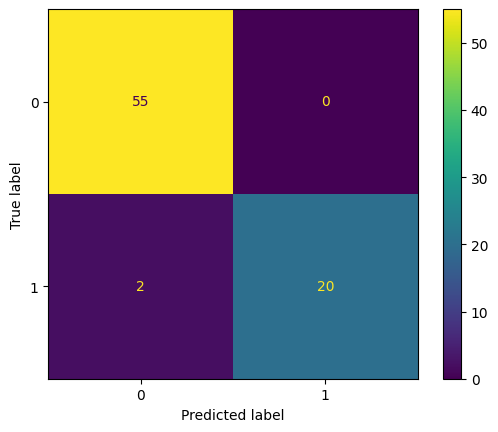

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (dt_hpt, metrics.classification_report(y_test, dt_hpt_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = dt_hpt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()


In [ ]:
dt_hpt_cv = cross_val_score(dt_hpt, X, y, cv=5, scoring='f1_weighted')

print(dt_hpt_cv)

print("%0.2f +/- %.2f" % (dt_hpt_cv.mean(), dt_hpt_cv.std()))

[0.96013074 0.94636591 0.89273183 0.98674091 0.11964189]
0.78 +/- 0.33


In [ ]:
dtrandom=DecisionTreeClassifier()

In [ ]:
dt_random_param_dict = {
     'max_depth':[1,2,3],
     'min_samples_leaf':[int(i) for i in np.linspace(1, 10, 10)],
     }


In [ ]:
dt_random_search = RandomizedSearchCV(estimator = dtrandom,
                                   param_distributions=dt_random_param_dict,
                                   cv=5)

In [ ]:
dt_random_search.fit(X_train_std, y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(),
                   param_distributions={'max_depth': [1, 2, 3],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 10]})

In [ ]:
dt_random_search.best_params_

{'min_samples_leaf': 5, 'max_depth': 3}

In [ ]:
dt_random_search.best_score_

np.float64(0.9574828133262823)

In [ ]:
dtran_hpt = DecisionTreeClassifier(max_depth=3,min_samples_leaf=5, random_state=42)

dtran_hpt.fit(X_train_std, y_train)
score_dtran_hpt = dtran_hpt.score(X_test_std, y_test)

print(score_dtran_hpt)

0.974025974025974


In [ ]:
dtrandom_pred=dtran_hpt.predict(X_test_std)
print(dtrandom_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.91      0.95        22

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.97        77
weighted avg       0.97      0.97      0.97        77




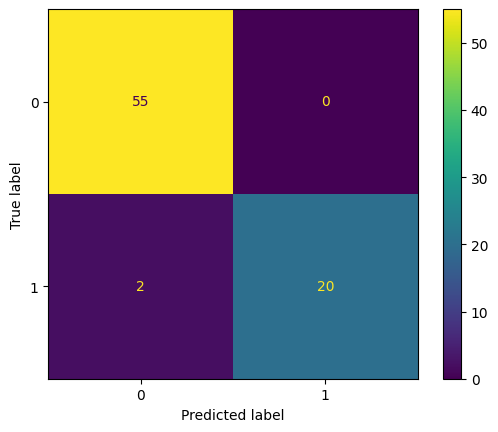

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (dtran_hpt, metrics.classification_report(y_test, dtrandom_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = dtrandom_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
dtran_cv = cross_val_score(dtran_hpt, X, y, cv=5, scoring='f1_weighted')

print(dtran_cv)

print("%0.2f +/- %.2f" % (dtran_cv.mean(), dtran_cv.std()))

[0.96013074 0.94636591 0.89273183 0.98674091 0.11964189]
0.78 +/- 0.33


**Random forest classifier**

In [ ]:
rand_clf=RandomForestClassifier()
rand_clf.fit(X_train,y_train)
rf_predicted =rand_clf.predict(X_test)
rf_score=rand_clf.score(X_test,y_test)
print(f'Classification accuracy of the raw data is {rf_score}')

Classification accuracy of the raw data is 0.961038961038961


In [ ]:
rd_pred = rand_clf.predict(X_test)
print(rd_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier RandomForestClassifier():
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        55
           1       1.00      0.86      0.93        22

    accuracy                           0.96        77
   macro avg       0.97      0.93      0.95        77
weighted avg       0.96      0.96      0.96        77




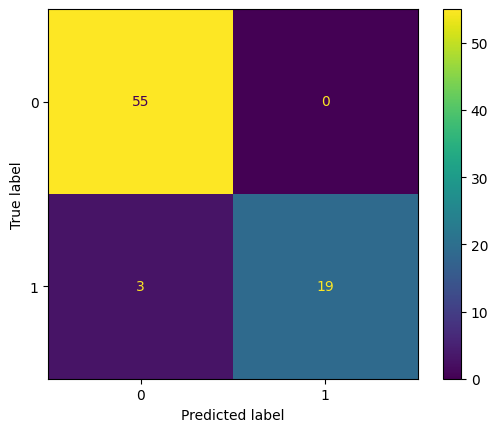

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (rand_clf, metrics.classification_report(y_test, rd_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = rd_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
rf_cv = cross_val_score(rand_clf, X, y, cv=5, scoring='f1_weighted')

print(rf_cv)

[0.96013074 0.94636591 0.91794141 0.96128874 0.67035235]


In [ ]:
print("%0.2f +/- %.2f" % (rf_cv.mean(), rf_cv.std()))

0.89 +/- 0.11


In [ ]:
rand_clf_std=RandomForestClassifier()
rand_clf_std.fit(X_train_std, y_train)
rf_score_std = rand_clf_std.score(X_test_std, y_test)

print(f'Classification accuracy after feature scaling is {rf_score_std}')

Classification accuracy after feature scaling is 0.961038961038961


In [ ]:
rfstd_pred = rand_clf_std.predict(X_test_std)
print(rfstd_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier RandomForestClassifier():
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        55
           1       1.00      0.86      0.93        22

    accuracy                           0.96        77
   macro avg       0.97      0.93      0.95        77
weighted avg       0.96      0.96      0.96        77




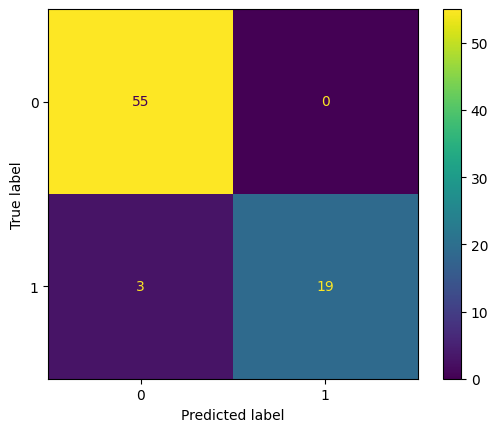

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (rand_clf_std, metrics.classification_report(y_test, rfstd_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = rfstd_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
rfstd_cv = cross_val_score(rand_clf_std, X, y, cv=5, scoring='f1_weighted')

print(rfstd_cv)

[0.96013074 0.93231406 0.93231406 0.93614355 0.71090791]


In [ ]:
print("%0.2f +/- %.2f" % (rfstd_cv.mean(), rfstd_cv.std()))

0.89 +/- 0.09


In [ ]:
rf_hpt=RandomForestClassifier()

In [ ]:
rf_hpt.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [ ]:
rf_hpt_param_grid = [
{
     'max_depth': [1,3,5],
     'n_estimators': [100]
     }
     ]

In [ ]:
rf_grid_search = GridSearchCV(estimator = rf_hpt,
                           param_grid = rf_hpt_param_grid,
                           cv = 5)

In [ ]:
rf_grid_search.fit(X_train_std, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [1, 3, 5], 'n_estimators': [100]}])

In [ ]:
print(rf_grid_search.best_params_)

{'max_depth': 5, 'n_estimators': 100}


In [ ]:
print(rf_grid_search.best_score_)

0.9574828133262823


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_hpt = RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42)


rf_hpt.fit(X_train_std, y_train)


score_rf_hpt = rf_hpt.score(X_test_std, y_test)

print(score_rf_hpt)

0.961038961038961


In [ ]:
rf_hpt_pred = rf_hpt.predict(X_test_std)
print(rf_hpt_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier RandomForestClassifier(max_depth=5, random_state=42):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        55
           1       1.00      0.86      0.93        22

    accuracy                           0.96        77
   macro avg       0.97      0.93      0.95        77
weighted avg       0.96      0.96      0.96        77




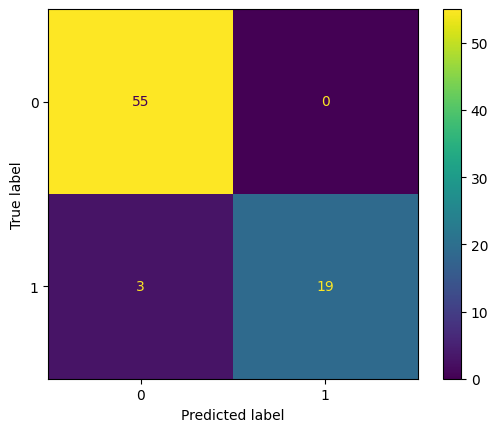

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (rf_hpt, metrics.classification_report(y_test, rf_hpt_pred)))

confMatrix = confusion_matrix(y_true = y_test, y_pred = rf_hpt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
rfhpt_cv = cross_val_score(rf_hpt, X, y, cv=5, scoring='f1_weighted')

print(rfhpt_cv)

print("%0.2f +/- %.2f" % (rfhpt_cv.mean(), rfhpt_cv.std()))

[0.96013074 0.93231406 0.93231406 0.96128874 0.50378743]
0.86 +/- 0.18


In [ ]:
rfrandom=RandomForestClassifier()

In [ ]:
rf_random_param_dict = {
     'max_depth': [1,3,5],
     'n_estimators': [100]
     }

In [ ]:
rf_randomsearch=RandomizedSearchCV(estimator=rfrandom,param_distributions=rf_random_param_dict,cv=5)

In [ ]:
rf_randomsearch.fit(X_train_std,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': [1, 3, 5],
                                        'n_estimators': [100]})

In [ ]:
rf_randomsearch.best_params_

{'n_estimators': 100, 'max_depth': 5}

In [ ]:
rf_randomsearch.best_score_

np.float64(0.9640401903754627)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfran_hpt = RandomForestClassifier(max_depth=8, min_samples_leaf=3, min_samples_split=5, n_estimators=100, random_state=42)

rfran_hpt.fit(X_train_std, y_train)

score_rfran_hpt = rfran_hpt.score(X_test_std, y_test)

print(score_rfran_hpt)

0.961038961038961


In [ ]:
rfran_pred = rfran_hpt.predict(X_test_std)
print(rfran_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier RandomForestClassifier(max_depth=8, min_samples_leaf=3, min_samples_split=5,
                       random_state=42):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        55
           1       1.00      0.86      0.93        22

    accuracy                           0.96        77
   macro avg       0.97      0.93      0.95        77
weighted avg       0.96      0.96      0.96        77




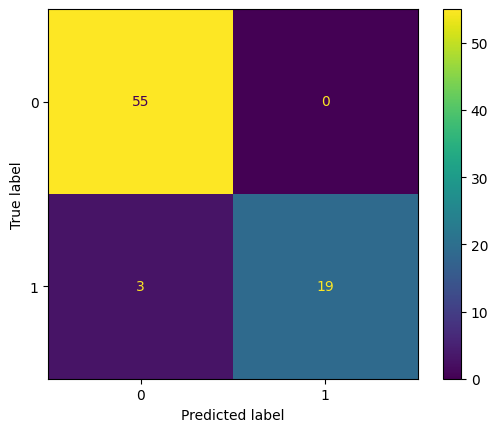

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (rfran_hpt, metrics.classification_report(y_test, rfran_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = rfran_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
rfran_cv = cross_val_score(rfran_hpt, X, y, cv=5, scoring='f1_weighted')

print(rfran_cv)

print("%0.2f +/- %.2f" % (rfran_cv.mean(), rfran_cv.std()))

[0.93231406 0.91794141 0.91794141 0.91134389 0.71090791]
0.88 +/- 0.08


**Adaboost**

In [ ]:
ab_clf=AdaBoostClassifier()
ab_clf.fit(X_train,y_train)
ab_predicted =ab_clf.predict(X_test)
ab_score=ab_clf.score(X_test,y_test)
print(f'Classification accuracy using raw data is {ab_score}')

Classification accuracy using raw data is 0.948051948051948


In [ ]:
ab_pred = ab_clf.predict(X_test)
print(ab_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier AdaBoostClassifier():
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        55
           1       0.91      0.91      0.91        22

    accuracy                           0.95        77
   macro avg       0.94      0.94      0.94        77
weighted avg       0.95      0.95      0.95        77




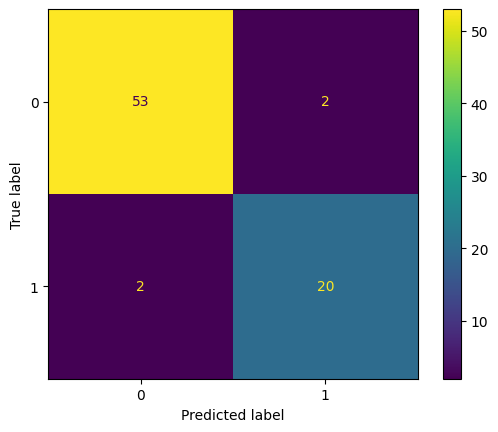

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (ab_clf, metrics.classification_report(y_test, ab_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = ab_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = ab_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = ab_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = ab_pred))

Precision: 0.909
Recall: 0.909
F1: 0.909


In [ ]:
from sklearn.model_selection import cross_val_score
ab_cv = cross_val_score(ab_clf, X, y, cv=5, scoring='f1_weighted')

print(ab_cv)

[0.94636591 0.93355123 0.93355123 0.96080424 0.82538377]


In [ ]:
print("%0.2f +/- %.2f" % (ab_cv.mean(), ab_cv.std()))

0.92 +/- 0.05


In [ ]:
ab_clf_std=AdaBoostClassifier()
ab_clf_std.fit(X_train_std,y_train)
abstd_score = ab_clf_std.score(X_test_std, y_test)
print(f'Classification accuracy of raw data is {ab_score}')

print(f'Classification accuracy after feature scaling is {abstd_score}')

Classification accuracy of raw data is 0.948051948051948
Classification accuracy after feature scaling is 0.948051948051948


In [ ]:
abstd_pred = ab_clf_std.predict(X_test_std)
print(abstd_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier AdaBoostClassifier():
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        55
           1       0.91      0.91      0.91        22

    accuracy                           0.95        77
   macro avg       0.94      0.94      0.94        77
weighted avg       0.95      0.95      0.95        77




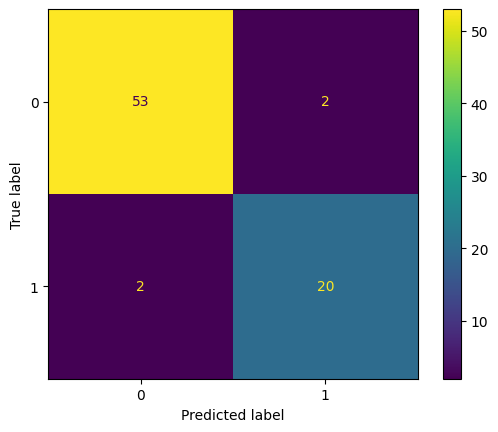

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (ab_clf_std, metrics.classification_report(y_test, abstd_pred)))

confMatrix = confusion_matrix(y_true = y_test, y_pred = abstd_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = abstd_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = abstd_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = abstd_pred))

Precision: 0.909
Recall: 0.909
F1: 0.909


In [ ]:
abstd_cv = cross_val_score(ab_clf_std, X, y, cv=5, scoring='f1_weighted')

print(abstd_cv)

[0.94636591 0.93355123 0.93355123 0.96080424 0.82538377]


In [ ]:
print("%0.2f +/- %.2f" % (abstd_cv.mean(), abstd_cv.std()))

0.92 +/- 0.05


In [ ]:
ab_hpt=AdaBoostClassifier()

In [ ]:
ab_hpt.get_params()

{'algorithm': 'deprecated',
 'estimator': None,
 'learning_rate': 1.0,
 'n_estimators': 50,
 'random_state': None}

In [ ]:
ab_hpt_param_grid = [
{
     'learning_rate': [i for i in range(1,10)],
     'n_estimators': [50, 100, 150],
     }
     ]

In [ ]:
ab_hpt_param_grid

[{'learning_rate': [1, 2, 3, 4, 5, 6, 7, 8, 9],
  'n_estimators': [50, 100, 150]}]

In [ ]:
ab_grid_search = GridSearchCV(estimator = ab_hpt,
                           param_grid = ab_hpt_param_grid,
                           cv = 5)

In [ ]:
ab_grid_search.fit(X_train_std, y_train)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(),
             param_grid=[{'learning_rate': [1, 2, 3, 4, 5, 6, 7, 8, 9],
                          'n_estimators': [50, 100, 150]}])

In [ ]:
print(ab_grid_search.best_params_)

{'learning_rate': 1, 'n_estimators': 50}


In [ ]:
ab_hpt = AdaBoostClassifier(learning_rate=1, n_estimators=50, random_state=42)
ab_hpt.fit(X_train_std, y_train)
score_ab_hpt = ab_hpt.score(X_test_std, y_test)
print(score_ab_hpt)

0.948051948051948


In [ ]:
ab_hpt_pred = ab_hpt.predict(X_test_std)
print(ab_hpt_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier AdaBoostClassifier(learning_rate=1, random_state=42):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        55
           1       0.91      0.91      0.91        22

    accuracy                           0.95        77
   macro avg       0.94      0.94      0.94        77
weighted avg       0.95      0.95      0.95        77




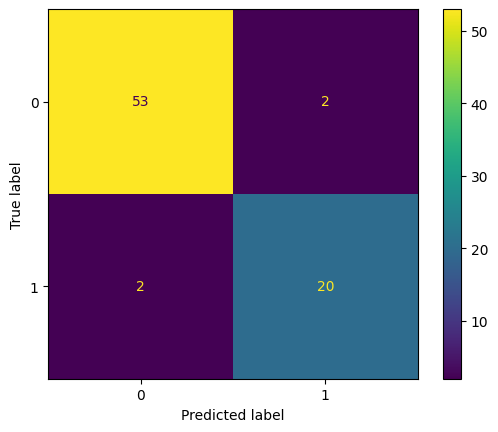

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (ab_hpt, metrics.classification_report(y_test, ab_hpt_pred)))


confMatrix = confusion_matrix(y_true = y_test, y_pred = ab_hpt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
ab_cv = cross_val_score(ab_hpt, X, y, cv=5, scoring='f1_weighted')

print(ab_cv)

print("%0.2f +/- %.2f" % (ab_cv.mean(), ab_cv.std()))

[0.94636591 0.93355123 0.93355123 0.96080424 0.82538377]
0.92 +/- 0.05


In [ ]:
abrandom=AdaBoostClassifier()

In [ ]:
ab_hpt_param_dict = {
    'learning_rate': [i for i in np.linspace(1,10,10)],
    'n_estimators': [50,100,150]
    }

In [ ]:
absearch = RandomizedSearchCV(estimator = abrandom,
                                   param_distributions=ab_hpt_param_dict,
                                   cv=5)

In [ ]:
absearch.fit(X_train_std, y_train)

RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(),
                   param_distributions={'learning_rate': [np.float64(1.0),
                                                          np.float64(2.0),
                                                          np.float64(3.0),
                                                          np.float64(4.0),
                                                          np.float64(5.0),
                                                          np.float64(6.0),
                                                          np.float64(7.0),
                                                          np.float64(8.0),
                                                          np.float64(9.0),
                                                          np.float64(10.0)],
                                        'n_estimators': [50, 100, 150]})

In [ ]:
absearch.best_params_

{'n_estimators': 100, 'learning_rate': np.float64(1.0)}

In [ ]:
absearch.best_score_

np.float64(0.9607615018508726)

In [ ]:
abrandom_hpt = AdaBoostClassifier(learning_rate=1, n_estimators=50,random_state=42)
abrandom_hpt.fit(X_train_std, y_train)
score_abrandom_hpt = abrandom_hpt.score(X_test_std, y_test)
print(score_abrandom_hpt)

0.948051948051948


In [ ]:
abrandom_pred=abrandom_hpt.predict(X_test_std)
print(abrandom_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0
 1 0 0]


Classification report for classifier AdaBoostClassifier(learning_rate=1, random_state=42):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        55
           1       0.91      0.91      0.91        22

    accuracy                           0.95        77
   macro avg       0.94      0.94      0.94        77
weighted avg       0.95      0.95      0.95        77




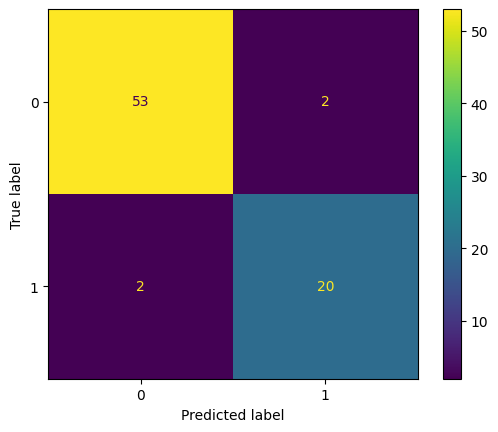

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (abrandom_hpt,metrics.classification_report(y_test, abrandom_pred)))

confMatrix = confusion_matrix(y_true = y_test, y_pred = abrandom_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
abran_cv = cross_val_score(abrandom, X, y, cv=5, scoring='f1_weighted')

print(abran_cv)

print("%0.2f +/- %.2f" % (abran_cv.mean(), abran_cv.std()))

[0.94636591 0.93355123 0.93355123 0.96080424 0.82538377]
0.92 +/- 0.05


**Gradient Boosting Classifier**

In [ ]:
gb_clf=GradientBoostingClassifier()
gb_clf.fit(X_train,y_train)

GradientBoostingClassifier()

In [ ]:
gb_predicted=gb_clf.predict(X_test)
gb_score=gb_clf.score(X_test,y_test)
print(f'Classification accuracy using raw data is {gb_score}')

Classification accuracy using raw data is 0.948051948051948


In [ ]:
gb_pred = gb_clf.predict(X_test)
print(gb_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier GradientBoostingClassifier():
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        55
           1       0.95      0.86      0.90        22

    accuracy                           0.95        77
   macro avg       0.95      0.92      0.93        77
weighted avg       0.95      0.95      0.95        77




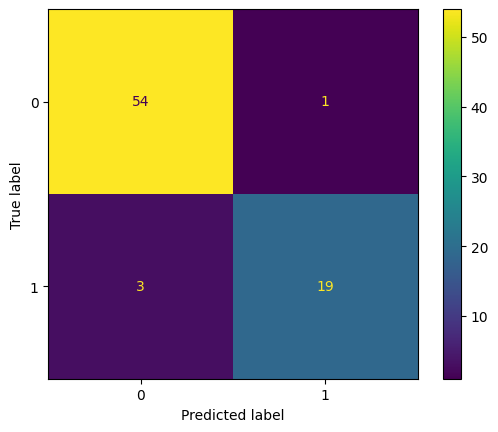

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (gb_clf, metrics.classification_report(y_test, gb_pred)))

confMatrix = confusion_matrix(y_true = y_test, y_pred = gb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = gb_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = gb_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = gb_pred))

Precision: 0.950
Recall: 0.864
F1: 0.905


In [ ]:
from sklearn.model_selection import cross_val_score
gb_cv = cross_val_score(gb_clf, X, y, cv=5, scoring='f1_weighted')

print(gb_cv)

[0.96013074 0.93231406 0.91954887 0.96080424 0.73713779]


In [ ]:
print("%0.2f +/- %.2f" % (gb_cv.mean(), gb_cv.std()))

0.90 +/- 0.08


In [ ]:
gb_clf_std=GradientBoostingClassifier()
gb_clf_std.fit(X_train_std,y_train)


GradientBoostingClassifier()

In [ ]:
gb_score_std=gb_clf_std.score(X_test_std,y_test)
print(f'Classification accuracy after feature scaling is {gb_score_std}')

Classification accuracy after feature scaling is 0.961038961038961


In [ ]:
gbstd_pred = gb_clf_std.predict(X_test_std)
print(gbstd_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier GradientBoostingClassifier():
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        55
           1       1.00      0.86      0.93        22

    accuracy                           0.96        77
   macro avg       0.97      0.93      0.95        77
weighted avg       0.96      0.96      0.96        77




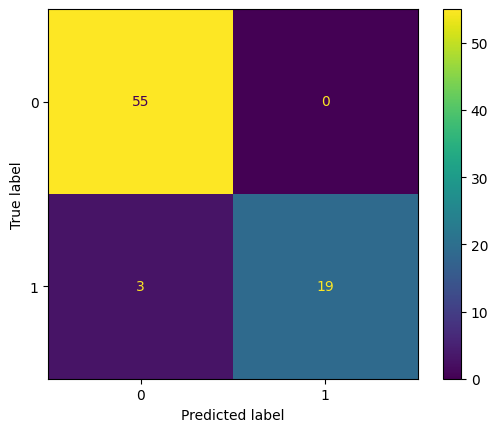

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (gb_clf_std, metrics.classification_report(y_test, gbstd_pred)))

confMatrix = confusion_matrix(y_true = y_test, y_pred = gbstd_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precision: %.3f' % precision_score(y_true = y_test, y_pred = gbstd_pred))
print('Recall: %.3f' % recall_score(y_true = y_test, y_pred = gbstd_pred))
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = gbstd_pred))

Precision: 1.000
Recall: 0.864
F1: 0.927


In [ ]:
from sklearn.model_selection import cross_val_score
gbstd_cv = cross_val_score(gb_clf_std, X, y, cv=5, scoring='f1_weighted')

print(gbstd_cv)

[0.96013074 0.93231406 0.91954887 0.96080424 0.73713779]


In [ ]:
print("%0.2f +/- %.2f" % (gbstd_cv.mean(), gbstd_cv.std()))

0.90 +/- 0.08


In [ ]:
gb_hpt=GradientBoostingClassifier()

In [ ]:
gb_hpt.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': None,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [ ]:
gb_hpt_param_grid = [
{
     'n_estimators': [100],
     'max_depth': [1,2,3],
     }
     ]

In [ ]:
gb_grid_search = GridSearchCV(estimator = gb_hpt,
                           param_grid = gb_hpt_param_grid,
                           cv = 5)

In [ ]:
gb_grid_search.fit(X_train_std, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid=[{'max_depth': [1, 2, 3], 'n_estimators': [100]}])

In [ ]:
print(gb_grid_search.best_params_)

{'max_depth': 1, 'n_estimators': 100}


In [ ]:
print(gb_grid_search.best_score_)

0.9607615018508724


In [ ]:
gb_hpt =GradientBoostingClassifier(max_depth=1, n_estimators=100, random_state=42)

gb_hpt.fit(X_train_std, y_train)

score_gb_hpt = gb_hpt.score(X_test_std, y_test)

print(score_gb_hpt)

0.974025974025974


In [ ]:
gb_hpt_pred = gb_hpt.predict(X_test_std)
print(gb_hpt_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier GradientBoostingClassifier(max_depth=1, random_state=42):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.91      0.95        22

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.97        77
weighted avg       0.97      0.97      0.97        77




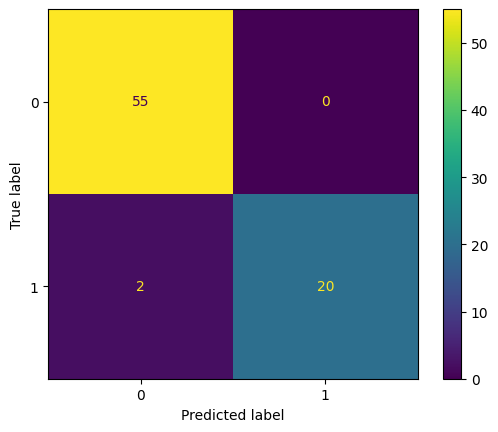

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (gb_hpt, metrics.classification_report(y_test, gb_hpt_pred)))

confMatrix = confusion_matrix(y_true = y_test, y_pred = gb_hpt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
print('F1: %.3f' % f1_score(y_true = y_test, y_pred = gb_hpt_pred))

F1: 0.952


In [ ]:
gb_cv = cross_val_score(gb_hpt, X, y, cv=5, scoring='f1_weighted')

print(gb_cv)

print("%0.2f +/- %.2f" % (gb_cv.mean(), gb_cv.std()))

[0.94636591 0.94636591 0.93231406 0.98674091 0.75004716]
0.91 +/- 0.08


In [ ]:
gbrandom=GradientBoostingClassifier()

gb_hpt_param_dict = {
     'n_estimators': [100],
     'max_depth': [1,2,3],
    }

In [ ]:
gb_randomsearch=RandomizedSearchCV(estimator=gbrandom,param_distributions=gb_hpt_param_dict,cv=5)

In [ ]:
gb_randomsearch.fit(X_train_std,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(),
                   param_distributions={'max_depth': [1, 2, 3],
                                        'n_estimators': [100]})

In [ ]:
gb_randomsearch.best_params_

{'n_estimators': 100, 'max_depth': 1}

In [ ]:
gb_randomsearch.best_score_

np.float64(0.9607615018508724)

In [ ]:
gbran_hpt =GradientBoostingClassifier(max_depth=1, n_estimators=100 , random_state=42)

gbran_hpt.fit(X_train_std, y_train)

score_gbran_hpt = gbran_hpt.score(X_test_std, y_test)

print(score_gbran_hpt)

0.974025974025974


In [ ]:
gbrandom_pred=gbran_hpt.predict(X_test_std)
print(gbrandom_pred)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0]


In [ ]:
print(y_test)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 1]


Classification report for classifier GradientBoostingClassifier(max_depth=1, random_state=42):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.91      0.95        22

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.97        77
weighted avg       0.97      0.97      0.97        77




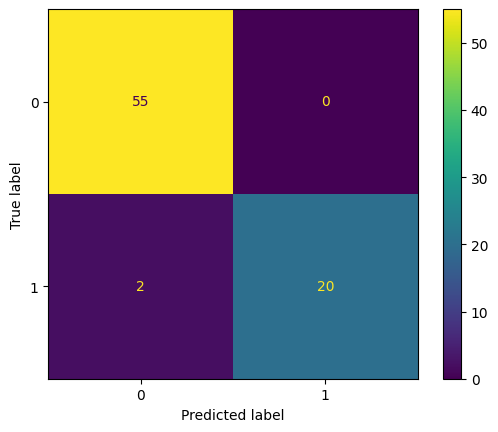

In [ ]:
print("Classification report for classifier %s:\n%s\n"
      % (gbran_hpt, metrics.classification_report(y_test, gbrandom_pred)))

confMatrix = confusion_matrix(y_true = y_test, y_pred = gbrandom_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confMatrix)

disp.plot()
plt.show()

In [ ]:
gbran_cv = cross_val_score(gb_randomsearch, X, y, cv=5, scoring='f1_weighted')

print(gbran_cv)

print("%0.2f +/- %.2f" % (gbran_cv.mean(), gbran_cv.std()))

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/

[0.94636591 0.94636591 0.93231406 0.98674091 0.75004716]
0.91 +/- 0.08


**Plotting model accuracies**

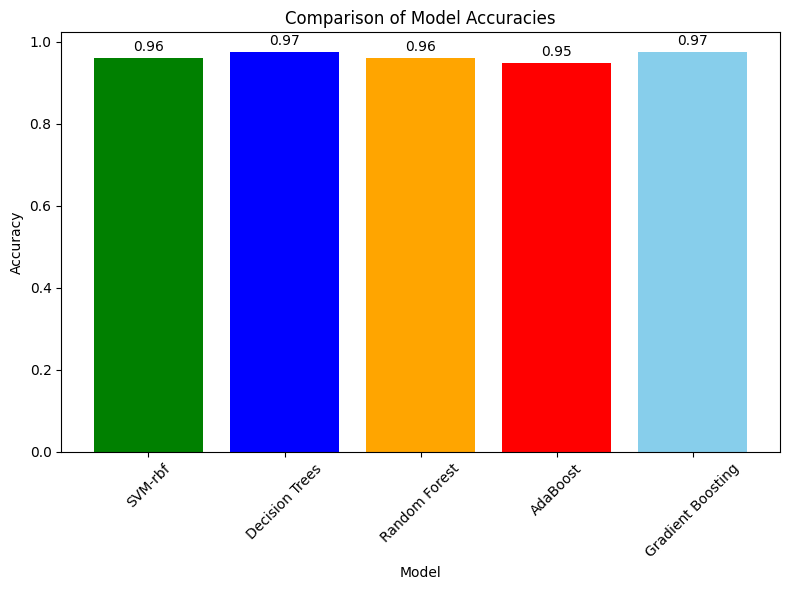

In [ ]:
model_names = ["SVM-rbf", "Decision Trees", "Random Forest","AdaBoost","Gradient Boosting"]\

accuracies = [score_svc_rbf, score_dt_hpt, score_rf_hpt,score_ab_hpt,score_gb_hpt]
if not all(isinstance(x, (int, float)) for x in accuracies):
    try:
        accuracies = [float(x) for x in accuracies]
    except ValueError:
        print("Error: Accuracies must be numerical values.")
        exit()


plt.figure(figsize=(8, 6))
histo=plt.bar(model_names, accuracies, color=['green', 'blue', 'orange','red','skyblue'])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.xticks(rotation=45)
plt.tight_layout()

for bar, accuracy in zip(histo, accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{accuracy:.2f}', ha='center', va='bottom')

plt.show()